## COMPAS - 2 OBJECTIVES

### Multi Layer Perceptron

* **Dataset:** Compass
* **Task:** Classification
* **Target:** Two year recidivism
* **Objectives:** Non-white and White individuals

In [45]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:
import numpy as np
import pandas as pd

from sklearn.metrics import log_loss
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim

In [47]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes
from machinemoo.analysis.metrics import compute_hypervolume_progress

from scalarization import MLPScalarization

### Dataset and Model

In [48]:
# Setting a seed for reproducibility
seed = 42

In [49]:
import random
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [50]:
data = pd.read_csv("dataset/compas_onerace.csv")
data = data.drop("Unnamed: 0", axis=1)

fair_feature = "not_white"
pred_feature = "Two_yr_Recidivism"

categories_fair_class = []

for index, row in data.iterrows():
    if row[pred_feature] == -1:
        categories_fair_class.append(row[fair_feature])
    else:
        categories_fair_class.append(row[fair_feature]+2)

X = data.drop([pred_feature], axis=1)
# y = data[pred_feature]
y = (data[pred_feature] + 1)//2

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = int(data.shape[0]*0.5),
                                                    stratify = categories_fair_class,
                                                    random_state = seed)

## MOO Modeling and Training

* MOO methods:
    * MOLA
    * MONISE
    * Random Weights

In [51]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 150,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
num_objs = 2
results = {}

In [52]:
# Logistic Regression with equal weight to use as baseline model
equal = MLPScalarization(
                        num_objs=2,
                        X=X_train, 
                        y=y_train, 
                        fair_feat=fair_feature,
                    )
equal.optimize(np.array([0.5, 0.5]))

## MOLA

23:24:27 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
23:24:27 | DEBUG | machinemoo | Finding 1th individual minimum
23:24:28 | DEBUG | machinemoo | Finding 2th individual minimum
23:24:29 | DEBUG | machinemoo | Calculated weights: [0.46270785 0.53729215]
23:24:29 | DEBUG | machinemoo | Importance: 0.014506569436435551
23:24:29 | DEBUG | machinemoo | Global lower bound (y*): [0.59233915 0.59624231]
23:24:29 | DEBUG | machinemoo | Iteration 1
23:24:29 | DEBUG | machinemoo | Solutions list: [array([0.59233915, 0.62324172]), array([0.62369062, 0.59624231])]
--- Logging error ---
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/usr/lib/pytho

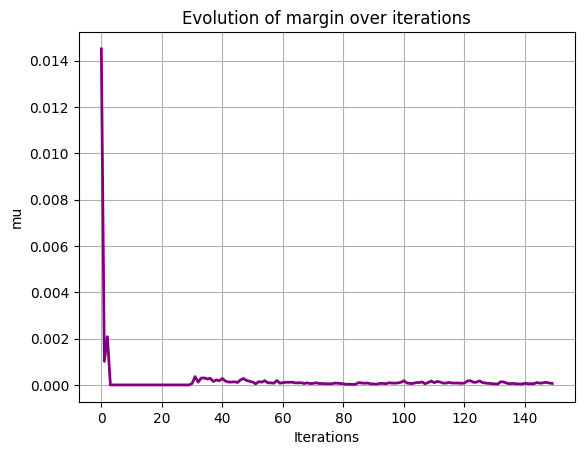

23:26:05 | INFO | machinemoo | Fit runtime: 98.94 seconds


In [53]:
method = 'mola'
w_scalar = MLPScalarization(num_objs=2, 
                            X=X_train, 
                            y=y_train,
                            fair_feat=fair_feature,
                            gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

In [54]:
objs_all = np.array([s.objs for s in moopt.history_list])

In [55]:
equal.objs

array([0.59372102, 0.60075042])

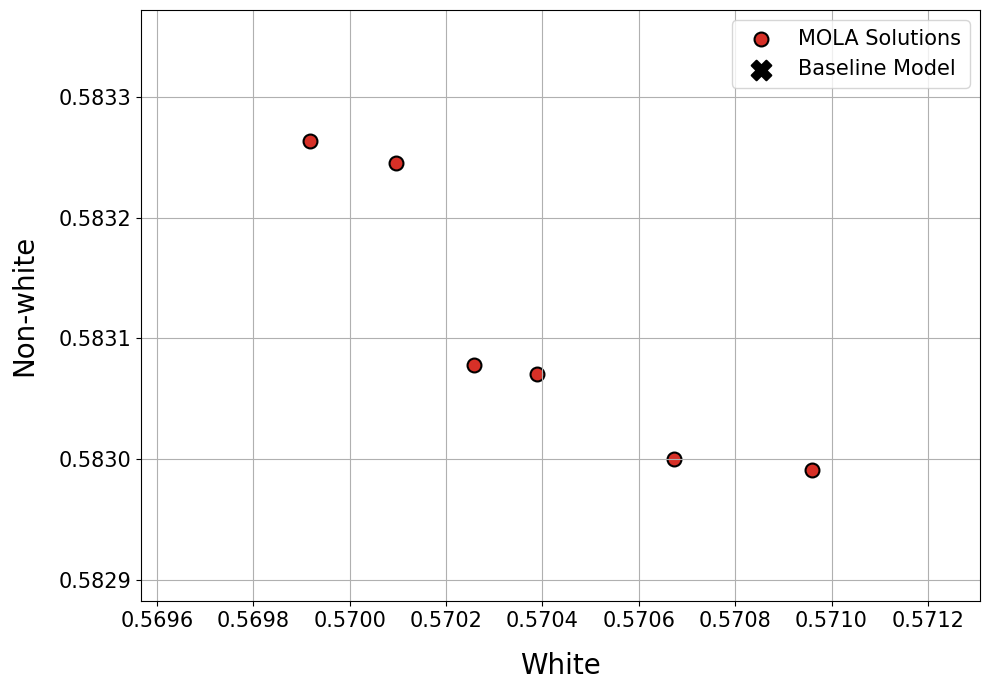

In [56]:
title="Loss Trade-offs for White and Non-White Person"
plot_pareto(methods={'mola': results['mola']['objectives']},
            labels=("White", "Non-White"), 
            title=title,
            point=equal.objs,
            fontsize=20,
            figsize=(10,7),
            save_path='images/2_objs_mlp_mola.pdf'
            )

23:26:06 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
23:26:06 | DEBUG | machinemoo | Finding 1th individual minimum
23:26:07 | DEBUG | machinemoo | Finding 2th individual minimum
23:26:07 | INFO | machinemoo | [Lipschitz] Updated global lower bounds: [  -4074.67266184 -728027.43792916]
23:26:07 | DEBUG | machinemoo | Calculated weights: [0. 1.]
23:26:07 | DEBUG | machinemoo | Importance: 728028.0356904734
23:26:07 | DEBUG | machinemoo | Global lower bound (y*): [  -4074.67266184 -728027.43792916]
23:26:07 | DEBUG | machinemoo | Iteration 1
23:26:07 | DEBUG | machinemoo | Solutions list: [array([0.5918786 , 0.62457084]), array([0.6154241 , 0.59776132])]
--- Logging error ---
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", l

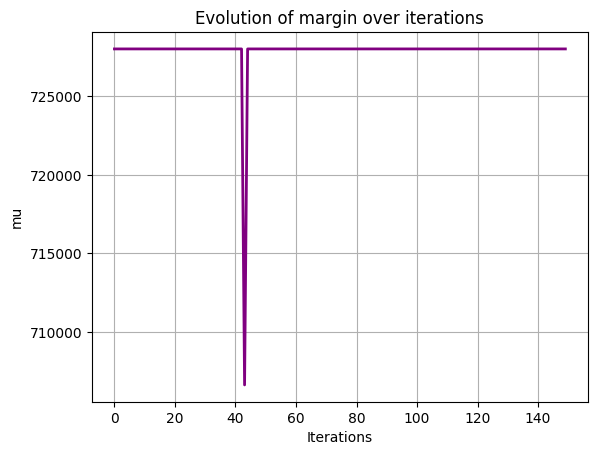

23:27:09 | INFO | machinemoo | Fit runtime: 63.19 seconds


In [57]:
method = 'mola'
w_scalar = MLPScalarization(num_objs=2, 
                            X=X_train, 
                            y=y_train,
                            fair_feat=fair_feature,
                            gradient=True
                            )
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f"{method}_grad"] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

In [58]:
results['mola_grad']['objectives']

array([[0.89684   , 0.58110765],
       [0.89297385, 0.58116246],
       [0.89003338, 0.58119689],
       [0.88874268, 0.58126789],
       [0.88785759, 0.58129581],
       [0.88550401, 0.5812962 ],
       [0.88545892, 0.58130337],
       [0.88519127, 0.58131099],
       [0.88431428, 0.58134541],
       [0.87901223, 0.58137293],
       [0.87816885, 0.5814159 ],
       [0.87712529, 0.58141703],
       [0.87113494, 0.58144434],
       [0.8711246 , 0.58145264],
       [0.86894205, 0.58145903],
       [0.86800903, 0.58148714],
       [0.86252925, 0.58151841],
       [0.86292909, 0.58151612],
       [0.85981253, 0.58155432],
       [0.85647661, 0.58159058],
       [0.85154989, 0.58161133],
       [0.8487194 , 0.58162863],
       [0.84752385, 0.58164528],
       [0.84623235, 0.58166427],
       [0.84151649, 0.58173317],
       [0.8402709 , 0.58176476],
       [0.84013445, 0.58181103],
       [0.83435235, 0.5818424 ],
       [0.83399521, 0.58185463],
       [0.83200403, 0.58188271],
       [0.

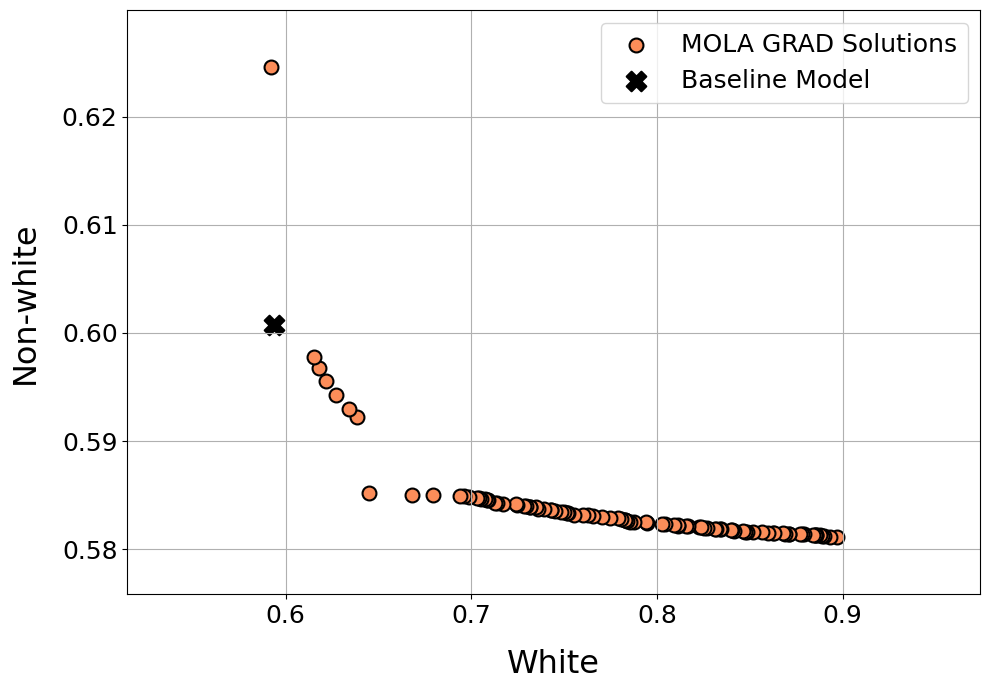

In [67]:
title="Loss Trade-offs for White and Non-White Person"
plot_pareto(methods={'mola_grad': results['mola_grad']['objectives']},
            color='#fc8d59',
            labels=("White", "Non-White"), 
            title=title,
            point=equal.objs,
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_mlp_mola_grad.pdf'
            )

## Random Weight

In [60]:
method = 'random_weight'
w_scalar = MLPScalarization(num_objs=2, 
                            X=X_train, 
                            y=y_train,
                            fair_feat=fair_feature,
                            gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

23:27:09 | WARNING | machinemoo | Ignored parameters for random_weights: {'targetGap', 'nodeGap', 'nodeTimeLimit'}
23:27:09 | DEBUG | machinemoo | Filtered parameters for random_weights: {'targetSize': 150, 'norm': False}
23:27:09 | DEBUG | machinemoo | Finding 1th individual minima
23:27:10 | DEBUG | machinemoo | Finding 2th individual minima
23:27:11 | DEBUG | machinemoo | 3th solution
23:27:11 | DEBUG | machinemoo | 4th solution
23:27:11 | DEBUG | machinemoo | 5th solution
23:27:11 | DEBUG | machinemoo | 6th solution
23:27:12 | DEBUG | machinemoo | 7th solution
23:27:12 | DEBUG | machinemoo | 8th solution
23:27:12 | DEBUG | machinemoo | 9th solution
23:27:12 | DEBUG | machinemoo | 10th solution
23:27:12 | DEBUG | machinemoo | 11th solution
23:27:13 | DEBUG | machinemoo | 12th solution
23:27:13 | DEBUG | machinemoo | 13th solution
23:27:13 | DEBUG | machinemoo | 14th solution
23:27:13 | DEBUG | machinemoo | 15th solution
23:27:13 | DEBUG | machinemoo | 16th solution
23:27:14 | DEBUG 

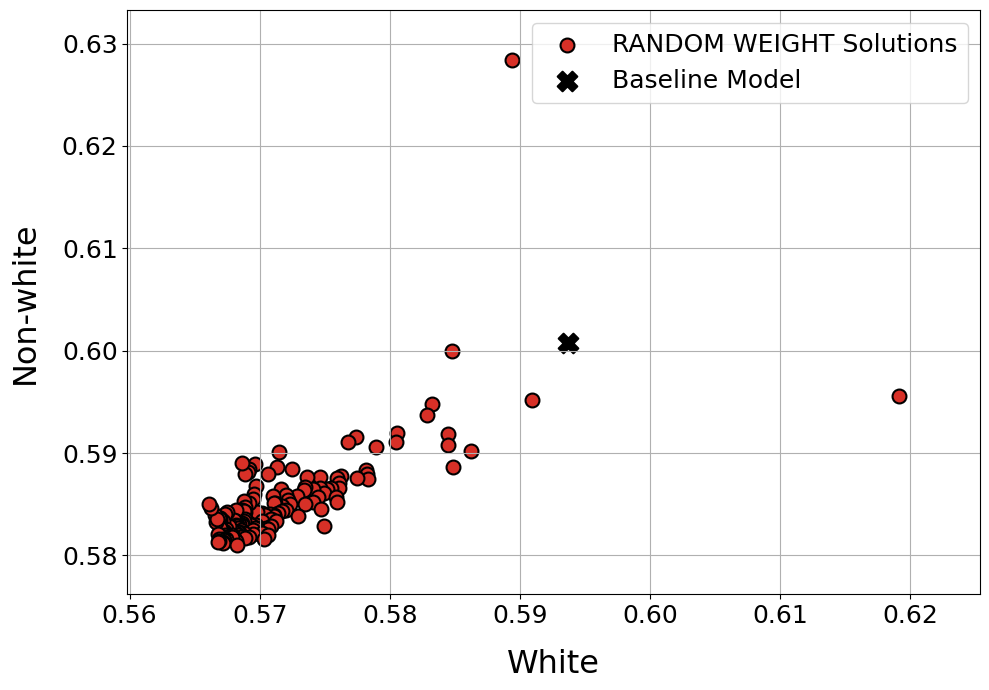

In [61]:
title="Loss Trade-offs for White and Non-White Person"
plot_pareto(methods={'random_weight': objs},
            labels=("White", "Non-White"), 
            title=title,
            point=equal.objs,
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_mlp_mola_rw.pdf'
            )

In [65]:
import numpy as np
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

# Supondo que `solutions` seja seu array (N x M)
solutions = results['random_weight']['objectives']

# Identifica os índices das soluções não-dominadas
nd_indices = NonDominatedSorting().do(solutions, only_non_dominated_front=True)

# Extrai as soluções não-dominadas
non_dominated_solutions = solutions[nd_indices]

print(f"Número de soluções não-dominadas: {len(non_dominated_solutions)}")
print(non_dominated_solutions)

Número de soluções não-dominadas: 8
[[0.56657865 0.58392793]
 [0.56665033 0.58327838]
 [0.5667908  0.5820501 ]
 [0.56624742 0.58466878]
 [0.56607907 0.584982  ]
 [0.56719653 0.58124283]
 [0.56822243 0.58102796]
 [0.56681449 0.58134456]]


In [70]:
len(results['mola']['objectives'])

6

In [71]:
len(results['mola_grad']['objectives'])

95

## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

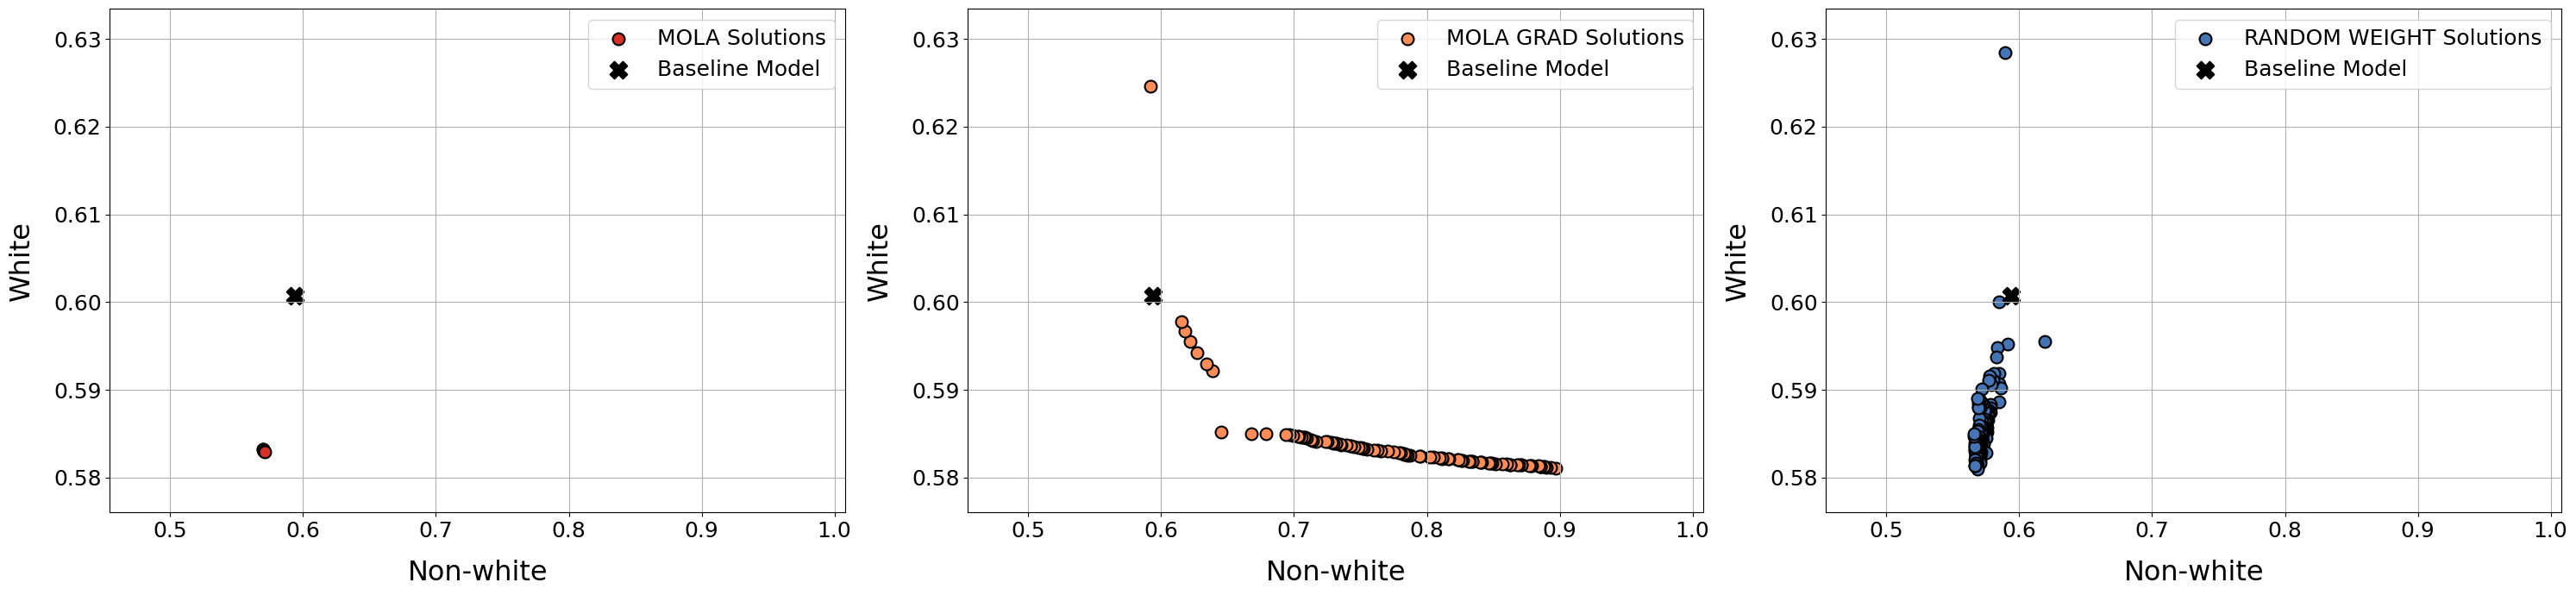

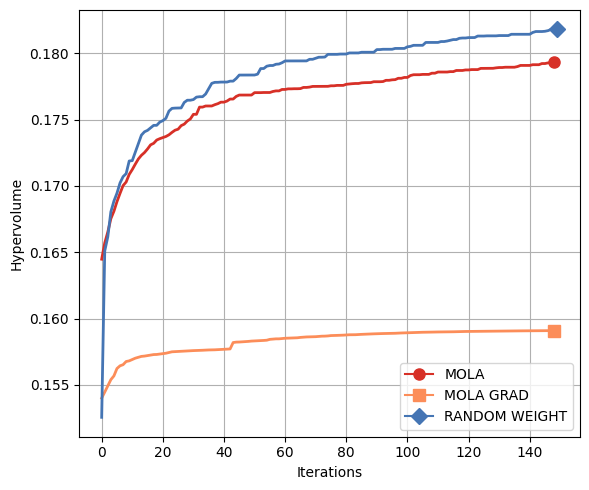

<Figure size 640x480 with 0 Axes>

In [62]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

axes_label = ["Non-White", "White"]
plot_pareto(methods=pareto_dict,
            labels=axes_label, 
            title=title,
            point=equal.objs,
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_mlp_methods.pdf'
            )

plot_multiple_hypervolumes(methods_hv=hypervolumes_dict, save_path="images/2_objs_mlp_hypervolume.pdf")

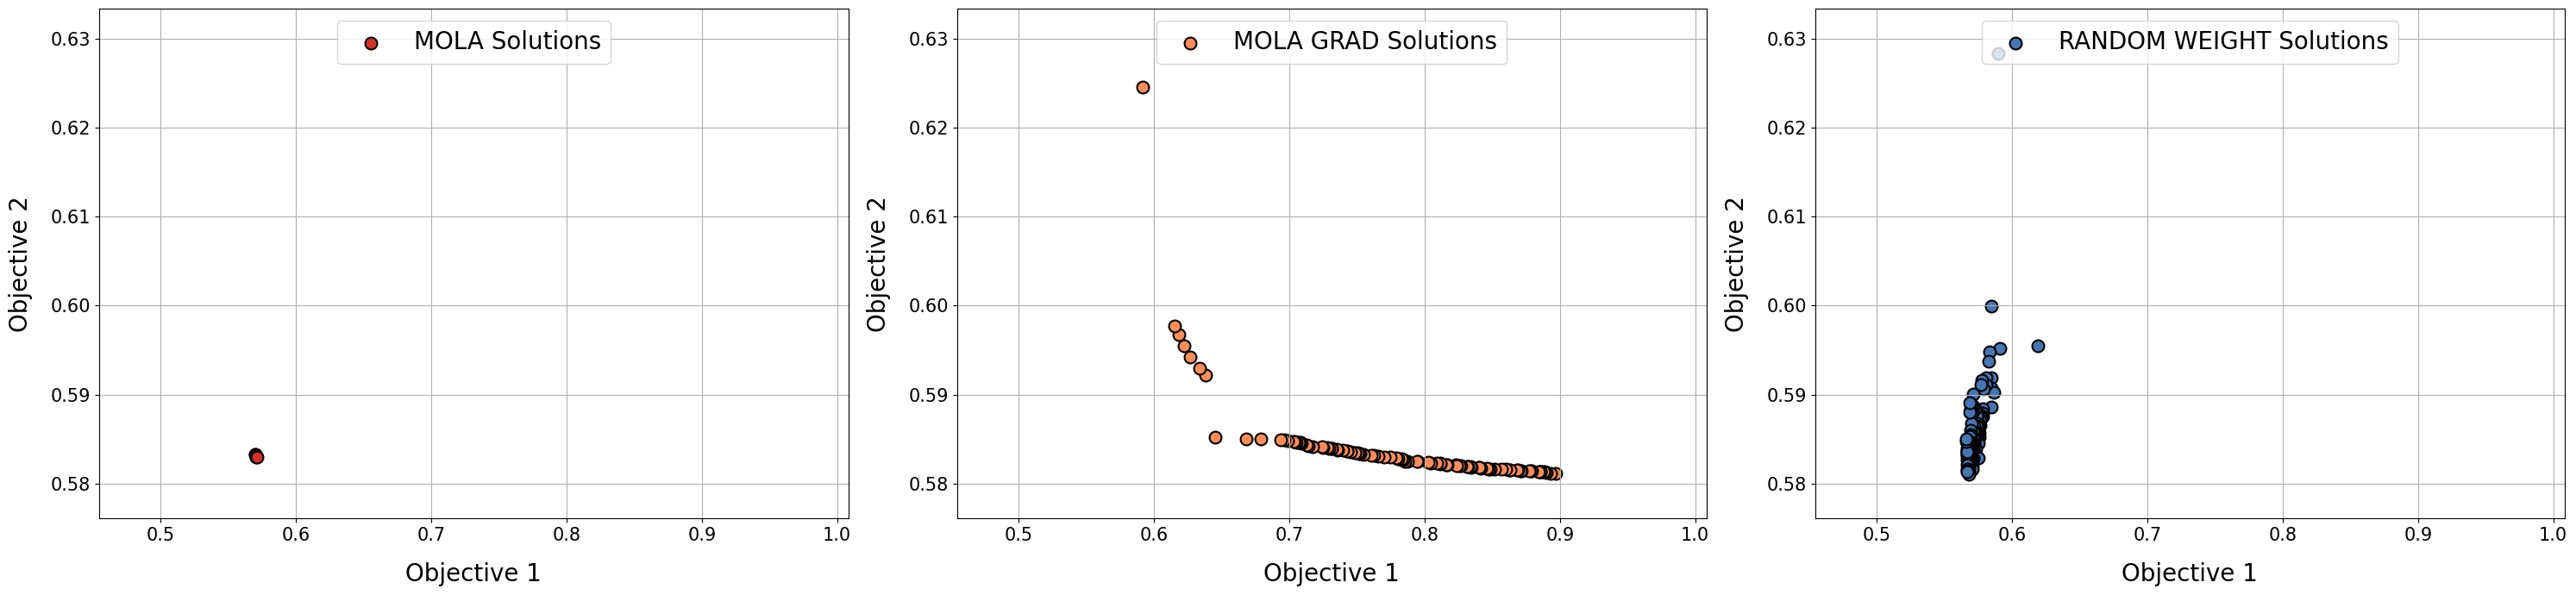

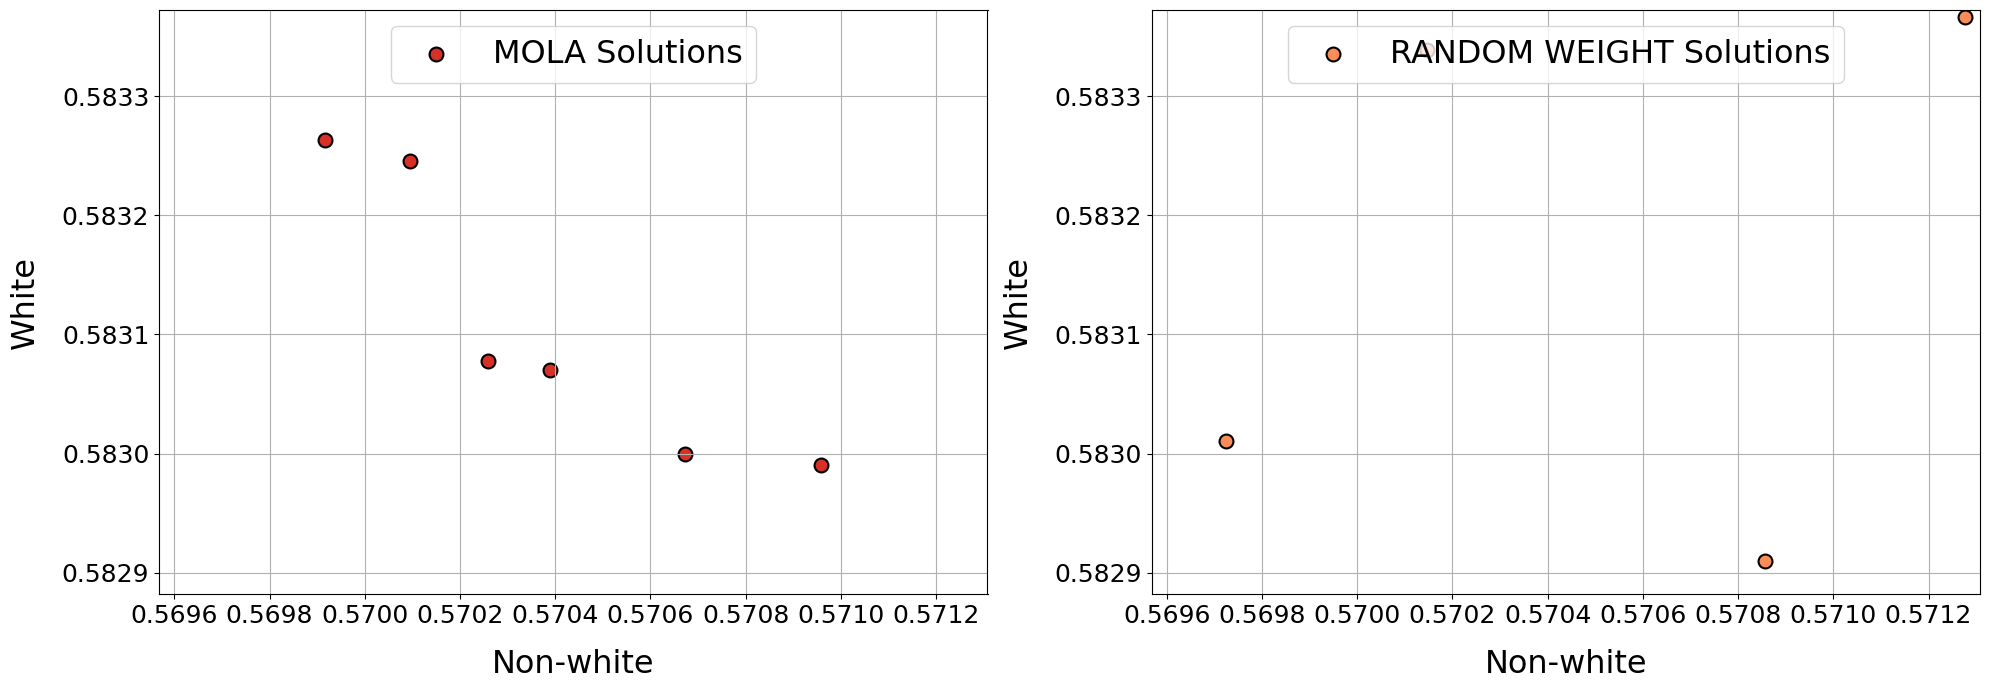

In [69]:
from machinemoo.analysis.visualization import plot_pareto_set_limit
plot_pareto_set_limit(methods=pareto_dict, axis_mode="global")
d = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res and method != "mola_grad"
    }

plot_pareto_set_limit(methods=d, 
                      axis_mode="first", 
                      title="",
                      labels=axes_label, 
                      fontsize=23,
                      figsize=(10,7),
                      save_path="images/2_objs_mlp_limit.pdf")

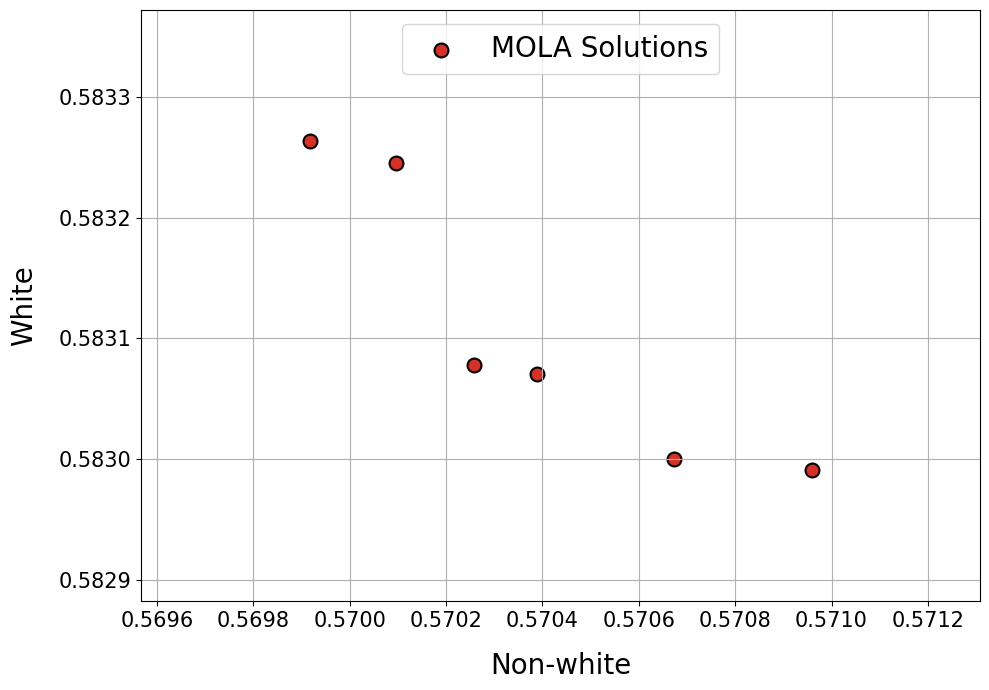

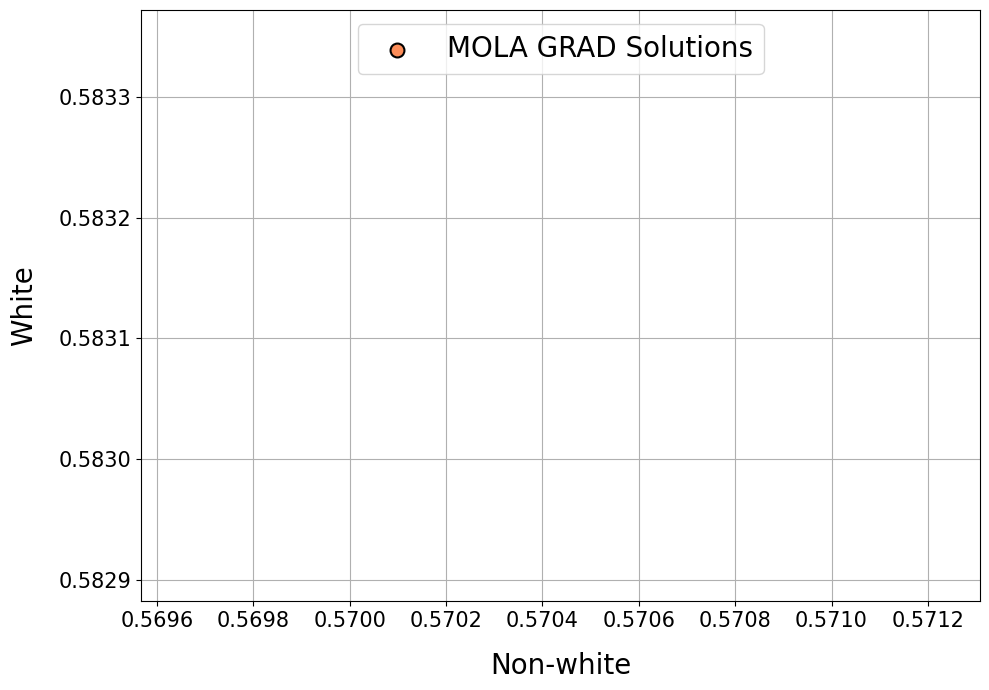

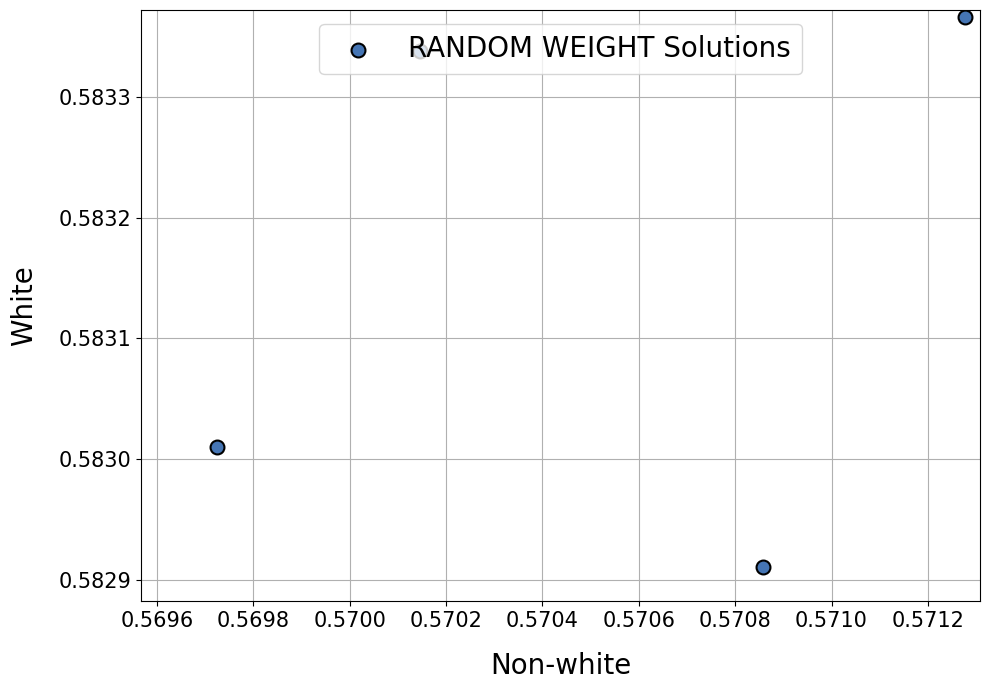

In [64]:
all_data = np.concatenate(list(pareto_dict.values()), axis=0)
limits = []
color: list[str] | str = ['#d73027', '#fc8d59', '#4575b4']

#for i in range(all_data.shape[1]):
#    limits.append(
#        (
#            all_data[:, i].min() - all_data[:, i].std(),
#            all_data[:, i].max() + all_data[:, i].std(),
#        )
#    )
first_objs = next(iter(pareto_dict.values()))
x_min, x_max = first_objs[:, 0].min() - first_objs[:, 0].std(), first_objs[:, 0].max() + first_objs[:, 0].std()
y_min, y_max = first_objs[:, 1].min() - first_objs[:, 1].std(), first_objs[:, 1].max() + first_objs[:, 1].std()

limits.append((x_min, x_max))
limits.append((y_min, y_max))

for i, (method, res) in enumerate(results.items()):
    plot_pareto(methods={method: res["objectives"]},
                color = color[i],
                labels=axes_label, 
                title=title,
                fontsize=20,
                figsize=(10,7),
                save_path=f'images/2_objs_mlp_{method}_limit.pdf',
                limits=limits
    )